# 配套实践 02-02：让网络从误差中学会动作

本练习延续 02-01 的桌面到达任务。我们先生成多条机械臂示范轨迹，再亲手完成两层网络的损失计算、反向传播和参数更新，最后检查训练曲线、未见位置上的动作预测和闭环到达过程。

<a href="https://qi-robotics.github.io/robot-world-model-tutorial/basics/02-how-neural-networks-learn/" target="_blank">在新标签页打开课程正文</a>

预计时间：20～25 分钟。不需要 GPU，也不需要下载外部数据。

## 使用方法

请从上到下运行全部单元格。练习使用 NumPy 明确写出前向计算和反向传播，使每一步都能与正文中的公式对应；后续使用 PyTorch 时，相同过程会由框架自动完成。

In [1]:
import numpy as np  # 导入 NumPy，用于构造数据和实现两层神经网络
import matplotlib.pyplot as plt  # 导入 Matplotlib，用于观察轨迹和训练结果

plt.rcParams["figure.dpi"] = 110  # 提高输出图片的显示清晰度
np.set_printoptions(precision=4, suppress=True)  # 让损失和梯度以易读格式显示
rng = np.random.default_rng(21)  # 固定数据随机种子，保证每次运行结果一致
print("环境准备完成")  # 提示依赖已经成功导入

环境准备完成


## 1. 生成多条机械臂示范轨迹

每条轨迹从一个随机相对位置开始。示范者根据目标距离给出动作：距离较远时限速，接近目标后减速，进入接触范围后停止。动作执行时加入很小的误差，用来模拟真实控制并不完全精确。

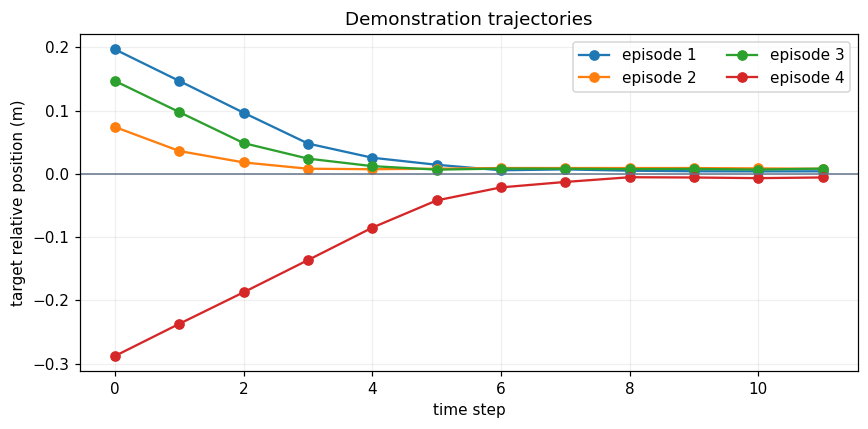

In [2]:
episode_count = 48  # 设置示范数据包含 48 条独立轨迹
steps_per_episode = 12  # 设置每条轨迹记录 12 个时间步
observations = np.zeros((episode_count, steps_per_episode, 2), dtype=np.float64)  # 创建形状为 [E,T,2] 的观测数组
demonstration_actions = np.zeros((episode_count, steps_per_episode, 1), dtype=np.float64)  # 创建形状为 [E,T,1] 的动作数组
start_distances = rng.uniform(-0.35, 0.35, size=episode_count)  # 为每条轨迹随机生成一个初始目标距离

for episode in range(episode_count):  # 依次生成每一条独立示范轨迹
    distance = start_distances[episode]  # 读取当前轨迹的初始目标距离
    for step in range(steps_per_episode):  # 按时间顺序生成当前轨迹中的观测和动作
        contact = float(abs(distance) < 0.012)  # 距离小于 1.2 厘米时视为已经接触目标
        proportional_action = 0.5 * distance  # 让示范动作先与目标距离成比例
        limited_action = np.clip(proportional_action, -0.05, 0.05)  # 限制机械臂单步最多移动 5 厘米
        action = 0.0 if contact > 0.5 else limited_action  # 已接触时停止，否则执行限速动作
        observations[episode, step] = [distance, contact]  # 保存当前目标距离和接触信号
        demonstration_actions[episode, step, 0] = action  # 保存示范者在当前时刻给出的动作
        execution_noise = rng.normal(0.0, 0.0012)  # 生成幅度很小的控制执行误差
        distance = distance - action + execution_noise  # 根据实际执行结果更新下一时刻的目标距离

fig, ax = plt.subplots(figsize=(8, 4))  # 创建用于显示示范轨迹的画布
for episode in range(4):  # 选择前四条轨迹进行展示
    ax.plot(np.arange(steps_per_episode), observations[episode, :, 0], marker="o", label=f"episode {episode + 1}")  # 画出目标距离随时间的变化
ax.axhline(0, color="#64748b", linewidth=1)  # 用水平线表示目标位置
ax.set_title("Demonstration trajectories")  # 设置图像标题
ax.set_xlabel("time step")  # 标明横轴是离散时间步
ax.set_ylabel("target relative position (m)")  # 标明纵轴是目标相对位置
ax.legend(ncol=2)  # 用两列图例区分四条轨迹
ax.grid(alpha=0.2)  # 添加浅色网格方便观察收敛过程
plt.tight_layout()  # 自动调整图像边距
plt.show()  # 显示四条示范轨迹

### 怎样理解这个结果

四条轨迹从不同位置开始：正值位于目标右侧，负值位于目标左侧。示范动作不断缩小相对距离，因此曲线逐渐接近零。末端执行中加入了很小的随机误差，所以曲线并非完全光滑。神经网络接下来要从所有轨迹中学习“当前距离和接触状态应该对应什么动作”。

## 2. 按完整轨迹划分并标准化数据

前 36 条轨迹作为训练集，后 12 条作为验证集。同一条轨迹不会同时出现在两边。标准化参数只用训练集计算，再原样应用到验证集。

In [3]:
train_episode_count = 36  # 指定前 36 条轨迹用于参数更新
x_train_raw = observations[:train_episode_count].reshape(-1, 2)  # 展平训练轨迹并保留两个观测分量
y_train_raw = demonstration_actions[:train_episode_count].reshape(-1, 1)  # 展平与训练观测对应的示范动作
x_valid_raw = observations[train_episode_count:].reshape(-1, 2)  # 展平没有参加参数更新的验证轨迹
y_valid_raw = demonstration_actions[train_episode_count:].reshape(-1, 1)  # 展平验证轨迹中的示范动作

x_mean = x_train_raw.mean(axis=0, keepdims=True)  # 只使用训练集计算每个输入分量的均值
x_std = x_train_raw.std(axis=0, keepdims=True) + 1e-6  # 只使用训练集计算标准差并避免除零
action_scale = 0.05  # 使用最大单步动作把输出缩放到大约负一到一
x_train = (x_train_raw - x_mean) / x_std  # 使用训练统计量标准化训练输入
x_valid = (x_valid_raw - x_mean) / x_std  # 对验证输入复用同一套训练统计量
y_train = y_train_raw / action_scale  # 把训练动作转换到便于优化的数值范围
y_valid = y_valid_raw / action_scale  # 使用相同尺度转换验证动作

print("训练样本：", x_train.shape, y_train.shape)  # 输出训练输入和目标动作的形状
print("验证样本：", x_valid.shape, y_valid.shape)  # 输出验证输入和目标动作的形状
print("训练输入均值：", x_mean.ravel())  # 输出稍后推理时仍需复用的训练均值
print("训练输入标准差：", x_std.ravel())  # 输出稍后推理时仍需复用的训练标准差

训练样本： (432, 2) (432, 1)
验证样本： (144, 2) (144, 1)
训练输入均值： [0.0041 0.5648]
训练输入标准差： [0.0845 0.4958]


### 怎样理解这个结果

36 条训练轨迹各有 12 步，因此得到 432 条训练样本；12 条验证轨迹得到 144 条验证样本。输入形状的最后一个数字是 2，对应目标距离和接触信号；输出最后一个数字是 1，对应水平动作。验证集没有用于计算均值、标准差或更新参数，因此可以检查模型面对未参与训练的轨迹时是否仍然有效。

## 3. 定义两层网络和反向传播

网络包含 2 个输入、12 个 ReLU 隐藏单元和 1 个输出。前向计算返回预测以及反向传播需要的中间结果；反向计算则根据均方误差得到四组参数梯度。

In [4]:
hidden_dim = 12  # 设置隐藏层包含 12 个可学习响应单元
model_rng = np.random.default_rng(8)  # 固定模型参数初始化的随机种子
W1 = model_rng.normal(0.0, 0.25, size=(2, hidden_dim))  # 初始化输入层到隐藏层的权重
b1 = np.zeros((1, hidden_dim))  # 把隐藏层偏置初始化为零
W2 = model_rng.normal(0.0, 0.25, size=(hidden_dim, 1))  # 初始化隐藏层到输出层的权重
b2 = np.zeros((1, 1))  # 把输出层偏置初始化为零

def forward(inputs, W1, b1, W2, b2):  # 定义从标准化观测到动作预测的前向计算
    hidden_linear = inputs @ W1 + b1  # 计算隐藏层激活前的线性结果
    hidden_activated = np.maximum(0.0, hidden_linear)  # 使用 ReLU 得到隐藏层响应
    predictions = hidden_activated @ W2 + b2  # 把隐藏响应组合成归一化动作预测
    return predictions, hidden_linear, hidden_activated  # 返回预测和反向传播需要的中间结果

def loss_and_gradients(inputs, targets, W1, b1, W2, b2):  # 定义均方误差及其手工反向传播
    predictions, hidden_linear, hidden_activated = forward(inputs, W1, b1, W2, b2)  # 先执行一次前向计算
    errors = predictions - targets  # 计算每条样本的预测动作与示范动作之差
    loss = np.mean(errors ** 2)  # 对所有样本的平方误差求平均
    prediction_gradient = 2.0 * errors / len(inputs)  # 计算损失对每个动作预测的梯度
    dW2 = hidden_activated.T @ prediction_gradient  # 计算输出层权重对损失的梯度
    db2 = prediction_gradient.sum(axis=0, keepdims=True)  # 计算输出层偏置对损失的梯度
    hidden_gradient = prediction_gradient @ W2.T  # 把输出误差传回隐藏层响应
    relu_gradient = (hidden_linear > 0.0).astype(np.float64)  # 正输入处保留梯度，负输入处关闭梯度
    hidden_linear_gradient = hidden_gradient * relu_gradient  # 得到损失对隐藏层线性结果的梯度
    dW1 = inputs.T @ hidden_linear_gradient  # 计算第一层权重对损失的梯度
    db1 = hidden_linear_gradient.sum(axis=0, keepdims=True)  # 计算第一层偏置对损失的梯度
    return loss, (dW1, db1, dW2, db2)  # 返回当前损失和四组参数梯度

initial_predictions, _, _ = forward(x_train, W1, b1, W2, b2)  # 使用随机参数计算初始训练预测
initial_train_loss = np.mean((initial_predictions - y_train) ** 2)  # 计算训练开始前的动作误差
print("W1 形状：", W1.shape, "W2 形状：", W2.shape)  # 输出两层权重的维度关系
print("训练前损失：", initial_train_loss)  # 输出随机网络尚未学习时的损失

W1 形状： (2, 12) W2 形状： (12, 1)
训练前损失： 0.2013454596638896


### 怎样理解这个结果

`W1` 的形状是 `[2,12]`，表示两个输入分别连接到 12 个隐藏单元；`W2` 的形状是 `[12,1]`，表示 12 个隐藏响应共同决定一个动作。此时参数只是随机数，损失仅说明随机预测与示范动作相差多远，并不表示网络已经理解任务。

## 4. 观察一次参数更新

先只取一个小 batch，计算四组梯度并更新一次。这样可以看见反向传播并不是抽象口号，而是在为每组参数产生与其形状相同的调整方向。

In [5]:
example_inputs = x_train[:32]  # 取前 32 条训练样本组成一个示例 batch
example_targets = y_train[:32]  # 取出与示例输入一一对应的动作目标
loss_before, gradients = loss_and_gradients(example_inputs, example_targets, W1, b1, W2, b2)  # 计算更新前损失和梯度
dW1, db1, dW2, db2 = gradients  # 按照网络层次拆开四组参数梯度
learning_rate = 0.03  # 设置本练习使用的参数更新步长
W1 -= learning_rate * dW1  # 沿第一层权重梯度的反方向更新参数
b1 -= learning_rate * db1  # 沿第一层偏置梯度的反方向更新参数
W2 -= learning_rate * dW2  # 沿输出层权重梯度的反方向更新参数
b2 -= learning_rate * db2  # 沿输出层偏置梯度的反方向更新参数
loss_after, _ = loss_and_gradients(example_inputs, example_targets, W1, b1, W2, b2)  # 使用更新后的参数重新计算同一 batch 损失
gradient_norms = [np.linalg.norm(dW1), np.linalg.norm(db1), np.linalg.norm(dW2), np.linalg.norm(db2)]  # 计算四组梯度的整体大小

print(f"更新前损失：{loss_before:.6f}")  # 输出参数更新前的 batch 损失
print(f"更新后损失：{loss_after:.6f}")  # 输出一次参数更新后的 batch 损失
print("梯度大小 [W1, b1, W2, b2]：", np.round(gradient_norms, 4))  # 输出各组参数这次收到的调整信号

更新前损失：0.310404
更新后损失：0.275736
梯度大小 [W1, b1, W2, b2]： [0.7162 0.421  0.5389 0.4735]


### 怎样理解这个结果

一次更新后，同一个 batch 的损失通常会小幅下降，说明参数沿着当前 batch 能够降低误差的方向移动。四个梯度大小不同，因为每组参数处于不同层、连接不同数量的输入。梯度小可能表示预测已经接近目标，也可能表示当前 ReLU 通路未开启或不同样本的调整要求互相抵消，不能仅凭一个梯度数值判断模型是否已经学会。

## 5. 在多个 batch 和 epoch 上训练

下面重复“取 batch、前向计算、计算损失、反向传播、更新参数”的过程。每个 epoch 结束后，分别记录训练损失和验证损失。

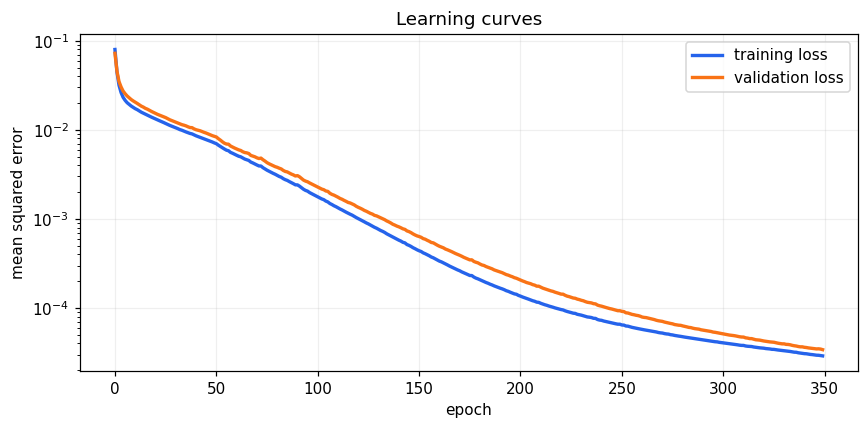

最终训练损失：0.000029
最终验证损失：0.000034


In [6]:
epoch_count = 350  # 设置完整遍历训练数据的次数
batch_size = 32  # 设置每次参数更新使用 32 条样本
train_losses = []  # 创建列表保存每个 epoch 的训练损失
valid_losses = []  # 创建列表保存每个 epoch 的验证损失

for epoch in range(epoch_count):  # 反复遍历训练集以逐渐调整参数
    shuffled_indices = rng.permutation(len(x_train))  # 在每个 epoch 开始时随机打乱训练样本顺序
    for start in range(0, len(x_train), batch_size):  # 按 batch 大小依次取出训练样本
        batch_indices = shuffled_indices[start:start + batch_size]  # 取得当前 batch 对应的样本索引
        batch_inputs = x_train[batch_indices]  # 根据索引取出当前 batch 的输入
        batch_targets = y_train[batch_indices]  # 根据相同索引取出目标动作
        _, gradients = loss_and_gradients(batch_inputs, batch_targets, W1, b1, W2, b2)  # 计算当前 batch 的参数梯度
        dW1, db1, dW2, db2 = gradients  # 拆开四组参数梯度
        W1 -= learning_rate * dW1  # 更新第一层权重
        b1 -= learning_rate * db1  # 更新第一层偏置
        W2 -= learning_rate * dW2  # 更新输出层权重
        b2 -= learning_rate * db2  # 更新输出层偏置
    train_predictions, _, _ = forward(x_train, W1, b1, W2, b2)  # 使用当前参数预测全部训练样本
    valid_predictions, _, _ = forward(x_valid, W1, b1, W2, b2)  # 使用当前参数预测全部验证样本
    train_losses.append(np.mean((train_predictions - y_train) ** 2))  # 记录当前 epoch 的训练损失
    valid_losses.append(np.mean((valid_predictions - y_valid) ** 2))  # 记录未参与更新的验证损失

fig, ax = plt.subplots(figsize=(8, 4))  # 创建用于显示训练过程的画布
ax.semilogy(train_losses, color="#2563eb", linewidth=2.2, label="training loss")  # 使用对数纵轴画出训练损失
ax.semilogy(valid_losses, color="#f97316", linewidth=2.2, label="validation loss")  # 在同一坐标中画出验证损失
ax.set_title("Learning curves")  # 设置图像标题
ax.set_xlabel("epoch")  # 标明横轴是完整训练轮数
ax.set_ylabel("mean squared error")  # 标明纵轴是均方误差
ax.legend()  # 显示两条曲线的含义
ax.grid(alpha=0.2)  # 添加浅色网格方便观察下降趋势
plt.tight_layout()  # 自动调整图像边距
plt.show()  # 显示训练和验证损失曲线

print(f"最终训练损失：{train_losses[-1]:.6f}")  # 输出最后一个 epoch 的训练损失
print(f"最终验证损失：{valid_losses[-1]:.6f}")  # 输出最后一个 epoch 的验证损失

### 怎样理解这个结果

纵轴采用对数刻度，因此相同的垂直距离代表数量级上的变化。训练初期两条曲线快速下降，说明网络正在学会左右方向、限速和停止关系；随后下降变慢，表示参数已经进入误差较低的区域。验证曲线与训练曲线保持接近，说明模型学到的关系能够用于未参加更新的轨迹，而不只是记住训练样本。

## 6. 检查未见位置上的动作关系

损失曲线只给出汇总数字。下面在一组连续位置上直接比较网络动作和示范规则，检查模型具体学会了什么。

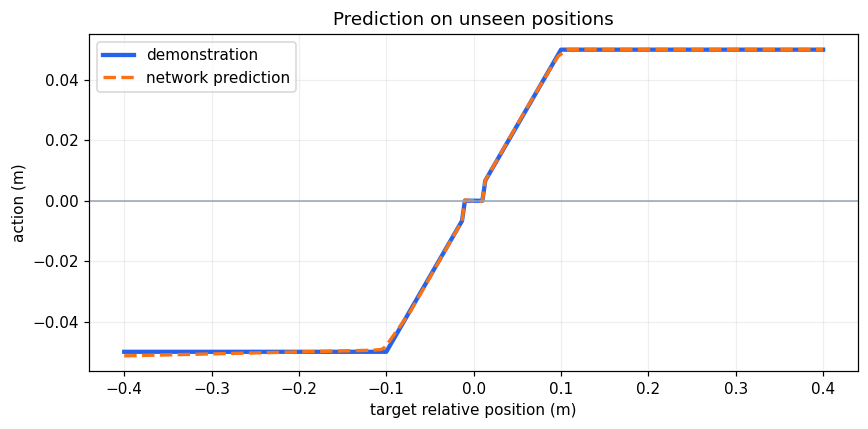

In [7]:
test_distances = np.linspace(-0.4, 0.4, 241)  # 生成覆盖训练范围及少量外部范围的连续位置
test_contacts = (np.abs(test_distances) < 0.012).astype(np.float64)  # 根据距离生成接触信号
test_inputs_raw = np.column_stack([test_distances, test_contacts])  # 把距离和接触信号组成模型输入
test_inputs = (test_inputs_raw - x_mean) / x_std  # 使用训练集统计量标准化测试输入
test_predictions_normalized, _, _ = forward(test_inputs, W1, b1, W2, b2)  # 计算连续位置上的归一化动作预测
test_predictions = test_predictions_normalized.ravel() * action_scale  # 把动作预测恢复成米
test_targets = np.where(test_contacts > 0.5, 0.0, np.clip(0.5 * test_distances, -0.05, 0.05))  # 计算同一位置上的示范动作

fig, ax = plt.subplots(figsize=(8, 4))  # 创建用于比较动作关系的画布
ax.plot(test_distances, test_targets, color="#2563eb", linewidth=2.8, label="demonstration")  # 画出希望网络学习的动作关系
ax.plot(test_distances, test_predictions, color="#f97316", linewidth=2.2, linestyle="--", label="network prediction")  # 画出训练后网络的动作预测
ax.axhline(0, color="#94a3b8", linewidth=1)  # 添加零动作参考线
ax.set_title("Prediction on unseen positions")  # 设置图像标题
ax.set_xlabel("target relative position (m)")  # 标明横轴是目标相对位置
ax.set_ylabel("action (m)")  # 标明纵轴是预测或示范动作
ax.legend()  # 显示两条曲线各自的含义
ax.grid(alpha=0.2)  # 添加浅色网格帮助观察局部差异
plt.tight_layout()  # 自动调整图像边距
plt.show()  # 显示未见位置上的动作预测

### 怎样理解这个结果

蓝线是示范规则，橙色虚线是网络预测。两条线方向一致，并在大部分位置接近，说明网络通过参数学会了基本动作关系；转折和停止区域仍可能存在小偏差，因为有限隐藏单元只能近似目标函数。图的最左和最右还稍微超出训练起点范围，那里的结果属于外推，应比训练范围内部更加谨慎地解释。

## 7. 把动作模型放回闭环

最后让训练后的网络连续控制几个未见起点。每一步都根据当前距离重新预测动作，再更新下一时刻距离。

In [ ]:
rollout_starts = np.array([-0.32, -0.17, 0.20, 0.34])  # 设置四个没有直接参加训练的闭环起点
rollout_steps = 12  # 设置每次闭环执行最多持续 12 步
rollout_histories = []  # 创建列表保存四次执行中的距离变化

for start_distance in rollout_starts:  # 依次从四个不同位置开始执行
    distance = float(start_distance)  # 把当前起点转换为便于更新的标量
    history = [distance]  # 先保存动作执行前的初始距离
    for step in range(rollout_steps):  # 让模型根据新观测连续预测动作
        contact = float(abs(distance) < 0.012)  # 根据当前距离计算接触信号
        model_input_raw = np.array([[distance, contact]])  # 组成当前时刻的一条结构化观测
        model_input = (model_input_raw - x_mean) / x_std  # 使用训练集统计量标准化当前观测
        predicted_normalized, _, _ = forward(model_input, W1, b1, W2, b2)  # 让网络预测当前时刻动作
        predicted_action = float(predicted_normalized[0, 0] * action_scale)  # 把网络输出恢复为米
        safe_action = float(np.clip(predicted_action, -0.05, 0.05))  # 把执行动作限制在允许范围内
        distance = distance - safe_action  # 根据动作更新下一时刻目标相对位置
        history.append(distance)  # 保存动作执行后的新距离
    rollout_histories.append(history)  # 保存从当前起点得到的完整闭环过程

fig, ax = plt.subplots(figsize=(8, 4))  # 创建用于显示闭环结果的画布
for start_distance, history in zip(rollout_starts, rollout_histories):  # 同时遍历四个起点及其执行记录
    ax.plot(np.arange(len(history)), history, marker="o", label=f"start {start_distance:+.2f} m")  # 画出每次执行中距离随时间的变化
ax.axhline(0, color="#64748b", linewidth=1)  # 用水平线表示理想目标位置
ax.set_title("Closed-loop rollouts with the learned network")  # 设置图像标题
ax.set_xlabel("control step")  # 标明横轴是连续控制步数
ax.set_ylabel("target relative position (m)")  # 标明纵轴是每一步重新观测的目标距离
ax.legend(ncol=2)  # 用两列图例标出不同起点
ax.grid(alpha=0.2)  # 添加浅色网格帮助观察是否接近目标
plt.tight_layout()  # 自动调整图像边距
plt.show()  # 显示网络在闭环中的连续执行结果

### 怎样理解这个结果

每条曲线都从不同位置出发，并在网络动作作用下逐步接近零。它比单独查看均方误差更接近机器人真正执行任务的情形，因为后一步输入取决于前一步动作产生的结果。如果某条曲线持续振荡、远离零或超过动作限制，即使离线损失很低，也说明模型还不能安全完成闭环任务。

## 练习与小结

1. 把 `hidden_dim` 从 12 改为 2 或 32，从定义网络的单元格重新运行，比较动作曲线。
2. 把学习率从 `0.03` 改为 `0.003` 或 `0.3`，观察训练速度和稳定性。
3. 只保留训练轨迹中目标位于右侧的样本，再检查网络能否推广到左侧。

本练习完成了从轨迹、样本、前向计算、损失、梯度和参数更新，到验证与闭环评价的完整训练过程。后续使用深度学习框架时，代码会更短，但每一步的语义不会改变。